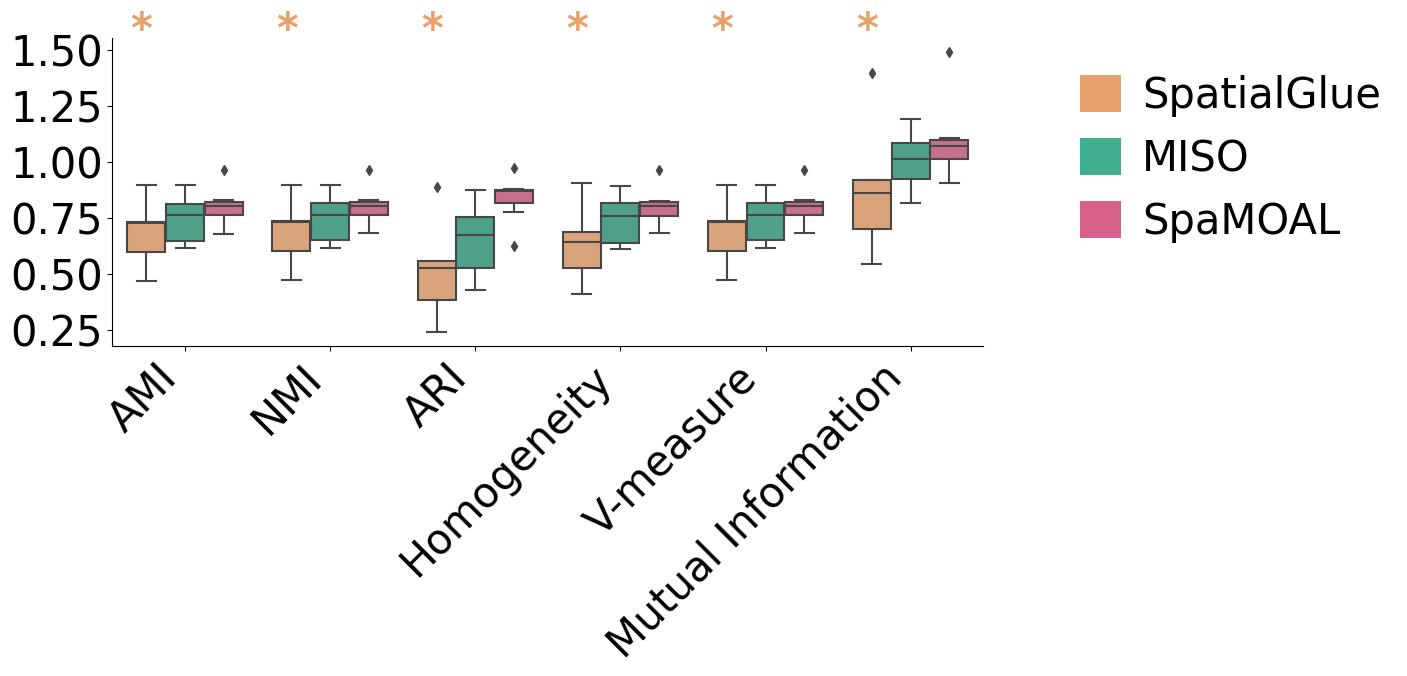

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# 您提供的数据
np.random.seed(10)
data = {
    'Method': np.repeat(['SpatialGlue', 'MISO', 'SpaMOAL'], 42),
    'Metric': np.tile(['AMI', 'NMI', 'ARI', 'Homogeneity', 'V-measure', 'Mutual Information'], 21),
    'Value': [
        0.7335, 0.7346, 0.5260, 0.6444, 0.7346, 0.8614,
        0.7335, 0.7346, 0.5260, 0.6444, 0.7346, 0.8614,
        0.7285, 0.7305, 0.5595, 0.6878, 0.7305, 0.9196,
        0.7285, 0.7305, 0.5595, 0.6878, 0.7305, 0.9196,
        0.4696, 0.4717, 0.2391, 0.4090, 0.4717, 0.5421,
        0.4696, 0.4717, 0.2391, 0.4090, 0.4717, 0.5421,
        0.8961, 0.8965, 0.8874, 0.9043, 0.8965, 1.3993,
        0.6163, 0.6176, 0.4292, 0.6118, 0.6176, 0.8178,
        0.8962, 0.8965, 0.8748, 0.8930, 0.8965, 1.1936,
        0.7626, 0.7642, 0.6723, 0.7588, 0.7642, 1.0145,
        0.6458, 0.6483, 0.5159, 0.6363, 0.6483, 0.8508,
        0.8266, 0.8271, 0.8114, 0.8277, 0.8271, 1.0971,
        0.8012, 0.8019, 0.6956, 0.8062, 0.8019, 1.0686,
        0.6490, 0.6504, 0.5374, 0.6431, 0.6504, 0.9952,
        0.8168, 0.8175, 0.8697, 0.8179, 0.8175, 1.0933,
        0.8279, 0.8285, 0.8806, 0.8273, 0.8285, 1.1059,
        0.8005, 0.8019, 0.8564, 0.7997, 0.8019, 1.0692,
        0.7223, 0.7242, 0.7783, 0.7189, 0.7242, 0.9611,
        0.6800, 0.6811, 0.6267, 0.6847, 0.6811, 0.9074,
        0.8039, 0.8045, 0.8699, 0.8045, 0.8045, 1.0662,
        0.9647, 0.9649, 0.9748, 0.9649, 0.9649, 1.4930,
    ]
}

df = pd.DataFrame(data)

# 定义指标和方法
metrics = ['AMI', 'NMI', 'ARI', 'Homogeneity', 'V-measure', 'Mutual Information']
methods = ['SpatialGlue', 'MISO', 'SpaMOAL']
comparison_pairs = [('SpaMOAL', 'SpatialGlue'), ('SpaMOAL', 'MISO')]

# 存储所有p值结果
results = []


for metric in metrics:
    # 获取每种方法在当前指标上的所有值
    values = {}
    for method in methods:
        values[method] = df[(df['Method'] == method) & (df['Metric'] == metric)]['Value'].values
    
    # 计算平均值
    means = {method: np.mean(values[method]) for method in methods}
    

    # 对每一对进行比较
    for method1, method2 in comparison_pairs:
        try:
            # 使用Wilcoxon signed-rank test
            stat, p = wilcoxon(values[method1], values[method2])
            test_used = "Wilcoxon"
        except:
            # 如果样本完全相同导致无法计算，使用Mann-Whitney U test
            stat, p = mannwhitneyu(values[method1], values[method2], alternative='two-sided')
            test_used = "Mann-Whitney"
        
        results.append({
            'Metric': metric,
            'Comparison': f'{method1} vs {method2}',
            'SpaMOAL_mean': means['SpaMOAL'],
            'Other_mean': means[method2],
            'p-value': p,
            'Test': test_used,
            'Significant': p < 0.05,
            'Highly_Significant': p < 0.01
        })
        
     

summary_df = pd.DataFrame(results)


pivot_table = summary_df.pivot(index='Metric', columns='Comparison', values='p-value').reset_index()
pivot_table.columns = ['Metric', 'SpaMOAL vs SpatialGlue', 'SpaMOAL vs MISO']

# 添加显著性标记
for col in ['SpaMOAL vs SpatialGlue', 'SpaMOAL vs MISO']:
    pivot_table[f'{col} (sig)'] = pivot_table[col].apply(
        lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else 'ns'))
    )


# Fisher's method 计算综合p值
def fisher_method(p_values_list):
    from scipy.stats import chi2
    p_values_list = [p for p in p_values_list if p > 0 and p <= 1]
    if len(p_values_list) == 0:
        return 1.0
    test_statistic = -2 * np.sum(np.log(p_values_list))
    df = 2 * len(p_values_list)
    combined_p = 1 - chi2.cdf(test_statistic, df)
    return combined_p

for comparison in ['SpaMOAL vs SpatialGlue', 'SpaMOAL vs MISO']:
    p_list = summary_df[summary_df['Comparison'] == comparison]['p-value'].values
    combined_p = fisher_method(p_list)
   

# 绘制带显著性标记的箱线图
plt.rcParams['font.size'] = 18
custom_colors = ['#E8A16D', '#40AE91', '#D6608A']

plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='Metric', y='Value', hue='Method', data=df, palette=custom_colors)

# 隐藏边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 计算每组内比较的显著性标记位置
y_max = df['Value'].max()
y_range = df['Value'].max() - df['Value'].min()
y_offset = y_range * 0.05

# 为每个指标添加两组比较的显著性标记
for i, metric in enumerate(metrics):
    # 获取该指标下三种方法的值
    values_metric = {}
    for method in methods:
        values_metric[method] = df[(df['Method'] == method) & (df['Metric'] == metric)]['Value'].values
    
    # 计算SpaMOAL vs SpatialGlue的p值
    _, p_vs_glue = wilcoxon(values_metric['SpaMOAL'], values_metric['SpatialGlue'])
    # 计算SpaMOAL vs MISO的p值
    _, p_vs_miso = wilcoxon(values_metric['SpaMOAL'], values_metric['MISO'])
    
    # 确定标记
    def sig_symbol(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return ''
    
    # 在图表顶部添加标记
    x_pos = i
    # 第一个比较标记（SpaMOAL vs SpatialGlue）
    y_pos_1 = y_max 
    # 第二个比较标记（SpaMOAL vs MISO）
    y_pos_2 = y_max + 0.08 * y_range
    
    # 添加图例标记
    ax.text(x_pos-0.3 , y_pos_1, f'{sig_symbol(p_vs_glue)}', 
            ha='center', va='bottom', fontsize=30, fontweight='bold', color=custom_colors[0])
    ax.text(x_pos , y_pos_2, f'{sig_symbol(p_vs_miso)}', 
            ha='center', va='bottom', fontsize=30, fontweight='bold', color=custom_colors[1])

# 图例
legend_elements = [
    Patch(facecolor=custom_colors[0], edgecolor='none', linewidth=0, label='SpatialGlue'),
    Patch(facecolor=custom_colors[1], edgecolor='none', linewidth=0, label='MISO'),
    Patch(facecolor=custom_colors[2], edgecolor='none', linewidth=0, label='SpaMOAL')
]
labels = ['AMI', 'NMI', 'ARI', 'Homogeneity', 'V-measure', 'Mutual Information']
ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.5, 1),
    fontsize=30,
    frameon=False,
    handlelength=1,
    handleheight=1,
    handletextpad=0.5,
    markerfirst=True,
    borderaxespad=0.5
)

ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=30)
plt.xlabel('')
plt.ylabel('')
plt.yticks(fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 1])

plt.savefig('boxplot_with_pairwise_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()

